# House Price Prediction — Supervised Learning Project

**Role:** Junior Data Scientist at a real estate analytics firm  
**Objective:** Build and evaluate multiple supervised learning models to predict house prices based on features like size, number of rooms, location score, and age of the property.

---

## Part A — Conceptual Understanding (Theory)

**Q1. What are Supervised Learning Algorithms?**

Supervised learning algorithms learn a mapping from input features (X) to an output label (y) using labeled training data. The model is trained by minimizing the error between its predictions and the actual known outputs. Once trained, it can predict outputs for new, unseen data. Examples: Linear Regression, Decision Trees, SVM.

---

**Q2. Difference between Regression and Classification Algorithms**

- **Regression** predicts a continuous numerical output. Example: predicting house price (₹23,00,000). Metrics: MSE, RMSE, R².
- **Classification** predicts a discrete class label. Example: predicting whether a house will sell or not (Yes/No). Metrics: Accuracy, Precision, Recall.

The key difference is the nature of the output — continuous vs categorical.

---

**Q3. Simple Linear Regression**

Simple Linear Regression models the linear relationship between one independent variable (X) and one dependent variable (y):

`y = β₀ + β₁X + ε`

where β₀ is the intercept, β₁ is the slope, and ε is the error term. The coefficients are estimated using Ordinary Least Squares (OLS) — minimizing the sum of squared residuals.

---

**Q4. Assumptions of Linear Regression**

1. **Linearity** — The relationship between X and y must be linear.
2. **Independence** — Observations must be independent of each other.
3. **Homoscedasticity** — Residuals must have constant variance across all fitted values.
4. **Normality of Residuals** — Residuals should be approximately normally distributed.
5. **No Multicollinearity** — Independent variables should not be highly correlated with each other (important for MLR).

---

**Q5. Bias–Variance Trade-Off**

- **Bias** is the error due to overly simplistic model assumptions. High bias means the model underfits — it misses important patterns.
- **Variance** is the error due to the model being too sensitive to the training data. High variance means the model overfits — it memorizes noise.
- The trade-off: reducing bias tends to increase variance and vice versa. The goal is to find a model complexity that minimizes total prediction error on unseen data.

---

**Q6. Overfitting and Underfitting**

- **Underfitting** occurs when the model is too simple to capture the patterns in data. Example: fitting a straight line to curved data — both training and test error are high.
- **Overfitting** occurs when the model is too complex and memorizes the training data including noise. Example: a high-degree polynomial that perfectly fits training points — training error is very low but test error is high.

---

## Part B — Dataset Understanding & Preparation

### Step 1 — Load the Dataset

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Lenovo\Downloads\sv learning project\sv learning dataset.csv")
print('Shape:', df.shape)
df.head()

Shape: (4200, 12)


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


### Step 2 — Basic Info and Data Types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


### Step 3 — Check for Missing Values

In [4]:
print(df.isnull().sum())

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64


No missing values. The dataset is clean.

### Step 4 — Basic Statistical Summary

In [5]:
df.describe()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


### Task 7 — Identify Independent and Dependent Variables

In [6]:
df = df.drop(columns=['house_id'])

X_cols = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score',
          'age_years', 'distance_city_km', 'lot_size_sqft',
          'has_garage', 'has_pool', 'renovation_years_ago']

y_col = 'house_price_inr'

print('Independent Variables (X):')
for col in X_cols:
    print(' -', col)

print('\nDependent Variable (y):', y_col)

Independent Variables (X):
 - area_sqft
 - bedrooms
 - bathrooms
 - location_score
 - age_years
 - distance_city_km
 - lot_size_sqft
 - has_garage
 - has_pool
 - renovation_years_ago

Dependent Variable (y): house_price_inr


### Task 8 — Visualize Relationships Between Features and Target Variable

**Distribution of the Target Variable (House Price)**

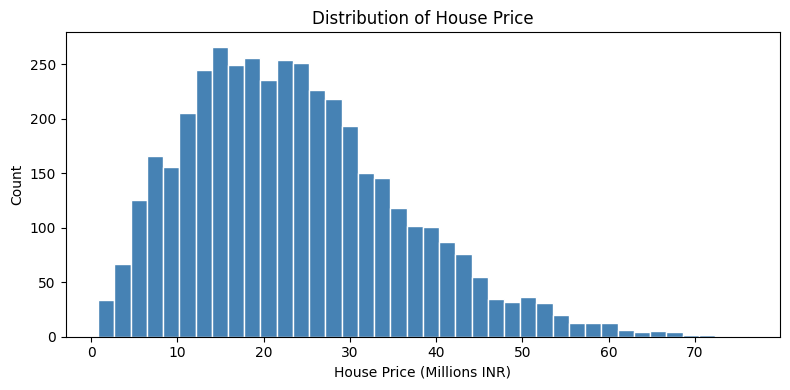

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df['house_price_inr'] / 1e6, bins=40, color='steelblue', edgecolor='white')
plt.xlabel('House Price (Millions INR)')
plt.ylabel('Count')
plt.title('Distribution of House Price')
plt.tight_layout()
plt.show()

The price distribution is roughly bell-shaped with a slight right skew.

**Scatter Plots — Numeric Features vs House Price**

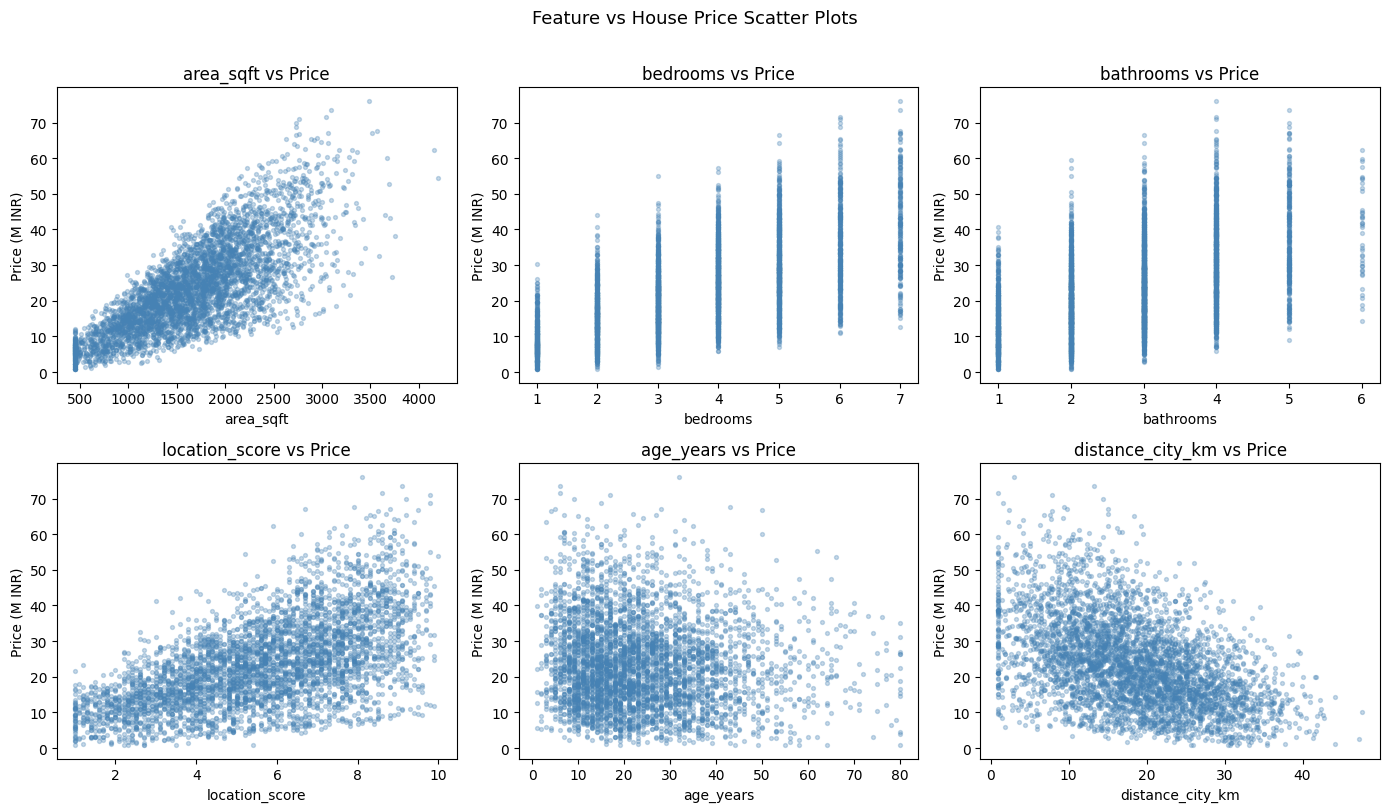

In [8]:
numeric_features = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    axes[i].scatter(df[feat], df['house_price_inr'] / 1e6, alpha=0.3, s=8, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price (M INR)')
    axes[i].set_title(f'{feat} vs Price')

plt.suptitle('Feature vs House Price Scatter Plots', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Correlation Heatmap**

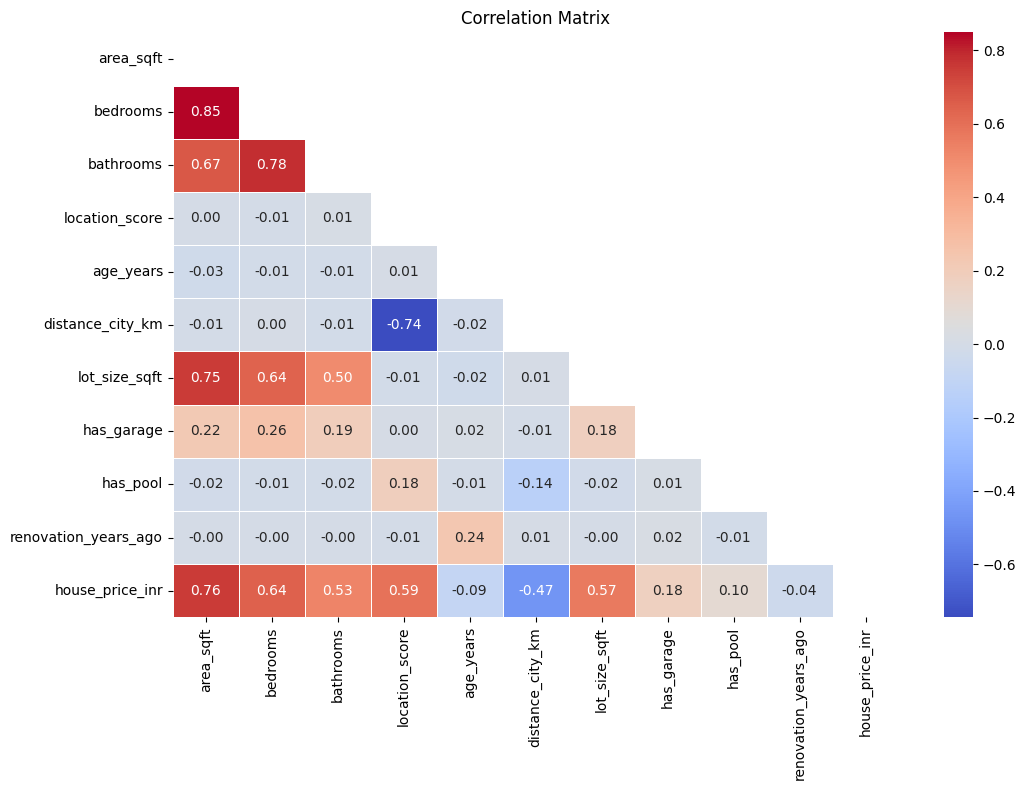

In [9]:
import seaborn as sns
import numpy as np

corr = df.corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

**Correlation of Each Feature with House Price**

In [10]:
corr_with_price = corr['house_price_inr'].drop('house_price_inr').sort_values(ascending=False)
print(corr_with_price)

area_sqft               0.755434
bedrooms                0.644772
location_score          0.588531
lot_size_sqft           0.567751
bathrooms               0.527044
has_garage              0.176934
has_pool                0.102015
renovation_years_ago   -0.037409
age_years              -0.089454
distance_city_km       -0.469431
Name: house_price_inr, dtype: float64


`area_sqft` and `location_score` show the highest positive correlation with price. `distance_city_km` and `age_years` are negatively correlated.

**Boxplots — Categorical Features vs House Price**

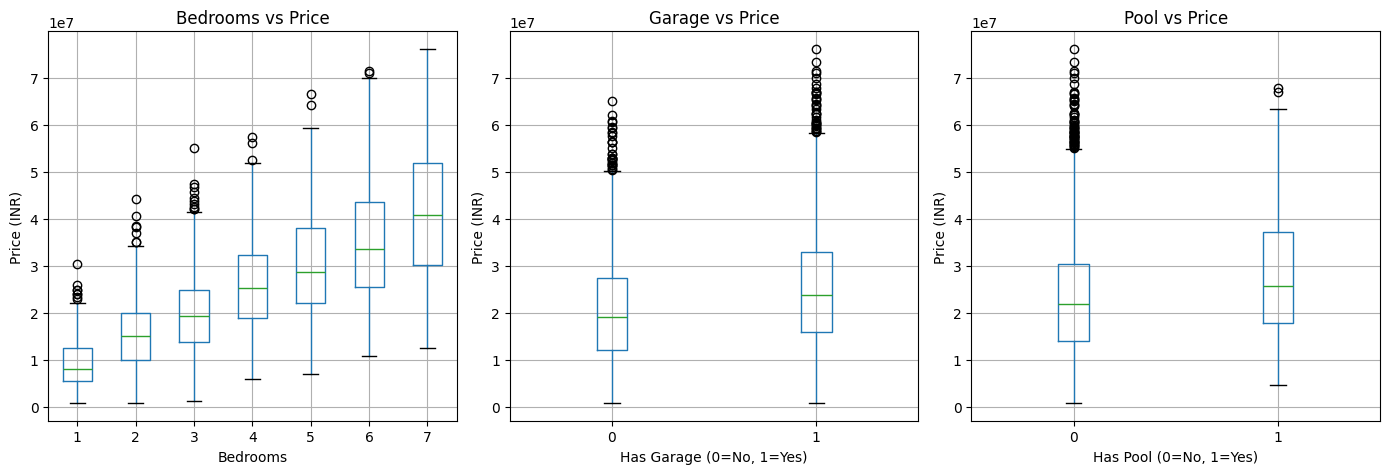

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

df.boxplot(column='house_price_inr', by='bedrooms', ax=axes[0])
axes[0].set_title('Bedrooms vs Price')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Price (INR)')

df.boxplot(column='house_price_inr', by='has_garage', ax=axes[1])
axes[1].set_title('Garage vs Price')
axes[1].set_xlabel('Has Garage (0=No, 1=Yes)')
axes[1].set_ylabel('Price (INR)')

df.boxplot(column='house_price_inr', by='has_pool', ax=axes[2])
axes[2].set_title('Pool vs Price')
axes[2].set_xlabel('Has Pool (0=No, 1=Yes)')
axes[2].set_ylabel('Price (INR)')

plt.suptitle('')
plt.tight_layout()
plt.show()

Houses with a garage or pool tend to have higher prices.

### Task 9 — Split the Dataset into Training and Testing Sets

In [13]:
from sklearn.model_selection import train_test_split

X = df[X_cols]
y = df[y_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples :', len(X_train))
print('Testing samples  :', len(X_test))

Training samples : 3360
Testing samples  : 840


We use an 80/20 split — 80% for training the model and 20% for evaluating it on unseen data.

---

## Part C — Simple Linear Regression

### Task 10 — Implement Simple Linear Regression using House Area

In [14]:
from sklearn.linear_model import LinearRegression

# Use only area_sqft as the single predictor
X_slr_train = X_train[['area_sqft']]
X_slr_test  = X_test[['area_sqft']]

In [15]:
slr = LinearRegression()
slr.fit(X_slr_train, y_train)

print(f'Intercept (β₀) : {slr.intercept_:,.2f}')
print(f'Slope     (β₁) : {slr.coef_[0]:,.2f}')

Intercept (β₀) : -1,163,519.18
Slope     (β₁) : 14,788.31


### Task 11 — Plot the Regression Line and Interpret Slope & Intercept

c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


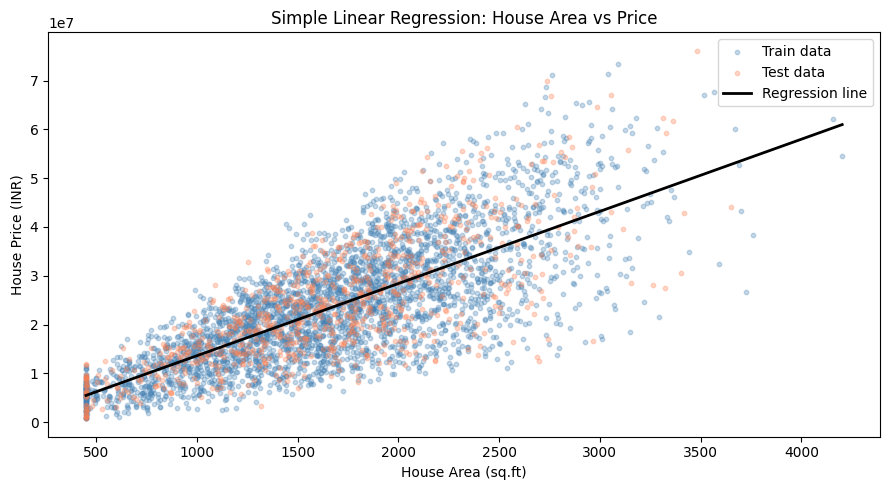

In [16]:
x_line = np.linspace(X['area_sqft'].min(), X['area_sqft'].max(), 200).reshape(-1, 1)
y_line = slr.predict(x_line)

plt.figure(figsize=(9, 5))
plt.scatter(X_slr_train, y_train, alpha=0.3, s=10, color='steelblue', label='Train data')
plt.scatter(X_slr_test, y_test, alpha=0.3, s=10, color='coral', label='Test data')
plt.plot(x_line, y_line, color='black', linewidth=2, label='Regression line')
plt.xlabel('House Area (sq.ft)')
plt.ylabel('House Price (INR)')
plt.title('Simple Linear Regression: House Area vs Price')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
print('Interpretation:')
print(f'  Slope (β₁)     : For every 1 sq.ft increase in area, price increases by ₹{slr.coef_[0]:,.0f}')
print(f'  Intercept (β₀) : The theoretical base price when area = 0 is ₹{slr.intercept_:,.0f}')
print('  (Intercept has no real-world meaning here; it is just the line\'s starting point.)')

Interpretation:
  Slope (β₁)     : For every 1 sq.ft increase in area, price increases by ₹14,788
  Intercept (β₀) : The theoretical base price when area = 0 is ₹-1,163,519
  (Intercept has no real-world meaning here; it is just the line's starting point.)


### Task 12 — Validate Linear Regression Assumptions

**Compute Residuals**

In [18]:
y_pred_train = slr.predict(X_slr_train)
residuals = y_train.values - y_pred_train

print('Residuals — first 5 values:')
print(residuals[:5])

Residuals — first 5 values:
[  1533937.4421622    8730819.05547668 -11685162.49290321
  -8582415.06511168    599221.00781951]


**Plot 1 — Residuals vs Fitted Values (checks Linearity & Homoscedasticity)**

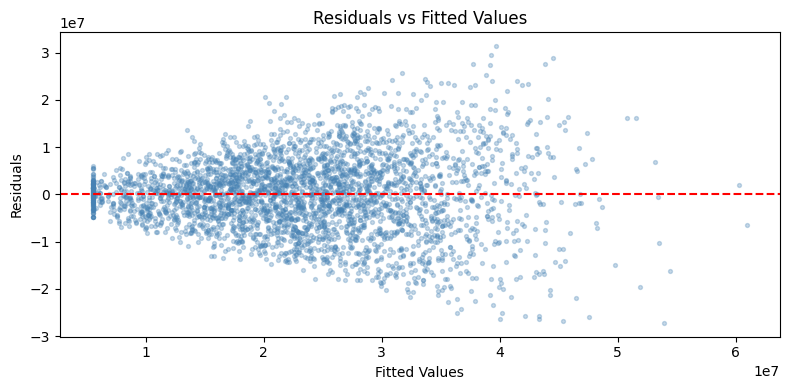

In [19]:
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_train, residuals, alpha=0.3, s=8, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.tight_layout()
plt.show()

Residuals should be randomly scattered around zero. A pattern here suggests non-linearity or heteroscedasticity.

**Plot 2 — Q-Q Plot (checks Normality of Residuals)**

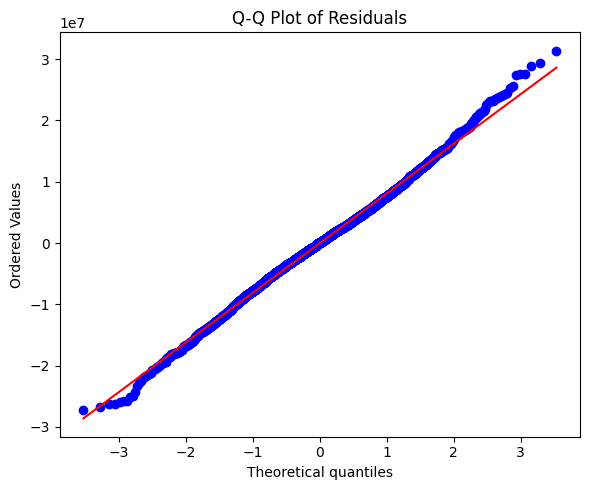

In [20]:
import scipy.stats as stats

plt.figure(figsize=(6, 5))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

Points following the diagonal line indicate that residuals are normally distributed.

**Plot 3 — Histogram of Residuals**

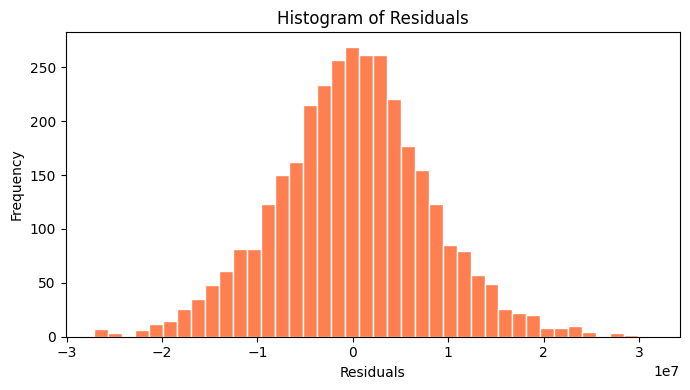

In [21]:
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=40, color='coral', edgecolor='white')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.tight_layout()
plt.show()

**Plot 4 — Scale-Location Plot (checks Homoscedasticity)**

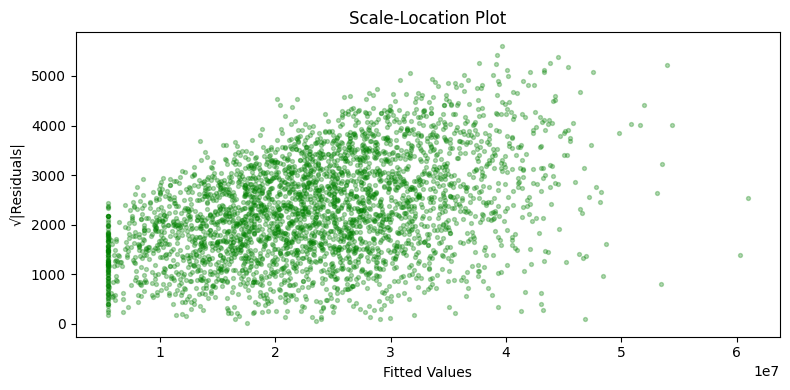

In [22]:
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_train, np.sqrt(np.abs(residuals)), alpha=0.3, s=8, color='green')
plt.xlabel('Fitted Values')
plt.ylabel('√|Residuals|')
plt.title('Scale-Location Plot')
plt.tight_layout()
plt.show()

**Assumption Check Summary:**

- **Linearity** — Mild non-linear pattern visible; area alone may not fully explain price.
- **Homoscedasticity** — Spread increases at higher fitted values — some heteroscedasticity present.
- **Normality** — Residuals are approximately normal with slight tails.
- **Independence** — Assumed based on dataset structure (individual house records).

---

## Part D — Model Evaluation Metrics

### Task 13 — Evaluate the Simple Linear Regression Model

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_test = slr.predict(X_slr_test)

In [24]:
mse = mean_squared_error(y_test, y_pred_test)
print(f'MSE  : {mse:,.0f}')

MSE  : 66,989,260,021,849


In [25]:
mae = mean_absolute_error(y_test, y_pred_test)
print(f'MAE  : {mae:,.0f}')

MAE  : 6,294,594


In [26]:
rmse = np.sqrt(mse)
print(f'RMSE : {rmse:,.0f}')

RMSE : 8,184,697


In [27]:
r2 = r2_score(y_test, y_pred_test)
print(f'R²   : {r2:.4f}')

R²   : 0.5625


In [28]:
n = len(y_test)
p = 1  # one feature in SLR
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'Adjusted R² : {adj_r2:.4f}')

Adjusted R² : 0.5620


### Task 14 — Interpret Each Metric

In [29]:
print('Metric Interpretations:')
print()
print(f'MSE  = {mse:,.0f}')
print('  Average squared error. Penalizes large errors more heavily. Hard to interpret directly.')
print()
print(f'MAE  = ₹{mae:,.0f}')
print('  On average, predictions are off by this amount in INR. Easy to understand.')
print()
print(f'RMSE = ₹{rmse:,.0f}')
print('  Same unit as house price. More sensitive to outliers than MAE.')
print()
print(f'R²   = {r2:.4f}')
print(f'  The model explains {r2*100:.1f}% of the variance in house prices.')
print()
print(f'Adj R² = {adj_r2:.4f}')
print('  Adjusts R² for number of predictors. Useful when comparing models with different feature counts.')

Metric Interpretations:

MSE  = 66,989,260,021,849
  Average squared error. Penalizes large errors more heavily. Hard to interpret directly.

MAE  = ₹6,294,594
  On average, predictions are off by this amount in INR. Easy to understand.

RMSE = ₹8,184,697
  Same unit as house price. More sensitive to outliers than MAE.

R²   = 0.5625
  The model explains 56.3% of the variance in house prices.

Adj R² = 0.5620
  Adjusts R² for number of predictors. Useful when comparing models with different feature counts.


An R² of ~0.56 means the model captures only about 56% of price variation — area alone is not enough. We need more features.

---

## Part E — Multiple Linear Regression

### Task 15 — Implement Multiple Linear Regression Using All Features

In [30]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

print('Model trained successfully.')
print(f'Intercept: {mlr.intercept_:,.2f}')

Model trained successfully.
Intercept: -14,766,762.75


In [31]:
coef_df = pd.DataFrame({'Feature': X_cols, 'Coefficient': mlr.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

             Feature   Coefficient
      location_score  3.073174e+06
            has_pool  4.552902e+05
            bedrooms  1.976431e+05
           bathrooms  1.859445e+05
    distance_city_km -9.896516e+04
          has_garage  9.392436e+04
           age_years -6.560924e+04
renovation_years_ago -2.143591e+04
           area_sqft  1.379594e+04
       lot_size_sqft  1.035058e+02


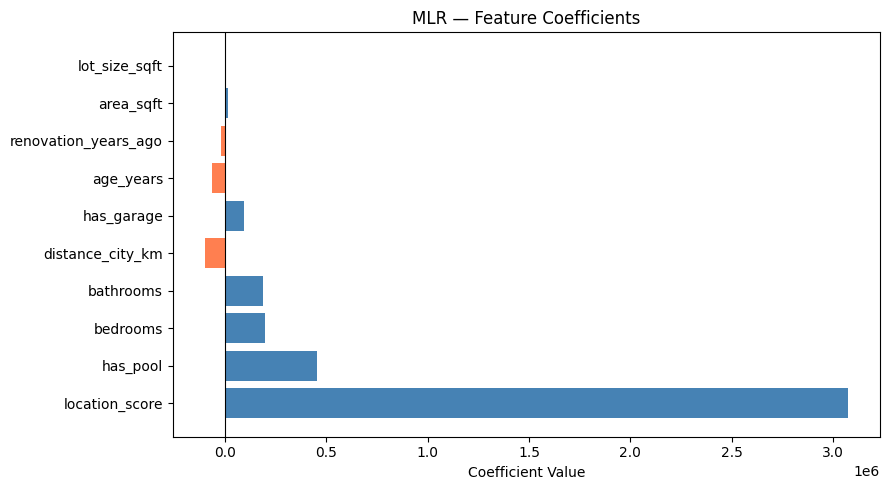

In [32]:
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]

plt.figure(figsize=(9, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('MLR — Feature Coefficients')
plt.tight_layout()
plt.show()

Positive coefficients (blue) increase price; negative ones (coral) decrease it.

### Task 16 — Evaluate MLR and Compare with SLR

In [33]:
y_pred_mlr = mlr.predict(X_test)

mse_mlr  = mean_squared_error(y_test, y_pred_mlr)
mae_mlr  = mean_absolute_error(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr   = r2_score(y_test, y_pred_mlr)

n = len(y_test)
p_mlr = len(X_cols)
adj_r2_mlr = 1 - (1 - r2_mlr) * (n - 1) / (n - p_mlr - 1)

print('MLR Metrics:')
print(f'  MSE     : {mse_mlr:,.0f}')
print(f'  MAE     : ₹{mae_mlr:,.0f}')
print(f'  RMSE    : ₹{rmse_mlr:,.0f}')
print(f'  R²      : {r2_mlr:.4f}')
print(f'  Adj. R² : {adj_r2_mlr:.4f}')

MLR Metrics:
  MSE     : 12,592,918,884,128
  MAE     : ₹2,604,991
  RMSE    : ₹3,548,650
  R²      : 0.9178
  Adj. R² : 0.9168


In [34]:
comparison = pd.DataFrame({
    'Metric'  : ['RMSE', 'MAE', 'R²', 'Adj. R²'],
    'SLR'     : [f'{rmse:,.0f}', f'{mae:,.0f}', f'{r2:.4f}', f'{adj_r2:.4f}'],
    'MLR'     : [f'{rmse_mlr:,.0f}', f'{mae_mlr:,.0f}', f'{r2_mlr:.4f}', f'{adj_r2_mlr:.4f}']
})
print(comparison.to_string(index=False))

 Metric       SLR       MLR
   RMSE 8,184,697 3,548,650
    MAE 6,294,594 2,604,991
     R²    0.5625    0.9178
Adj. R²    0.5620    0.9168


**Actual vs Predicted — SLR vs MLR**

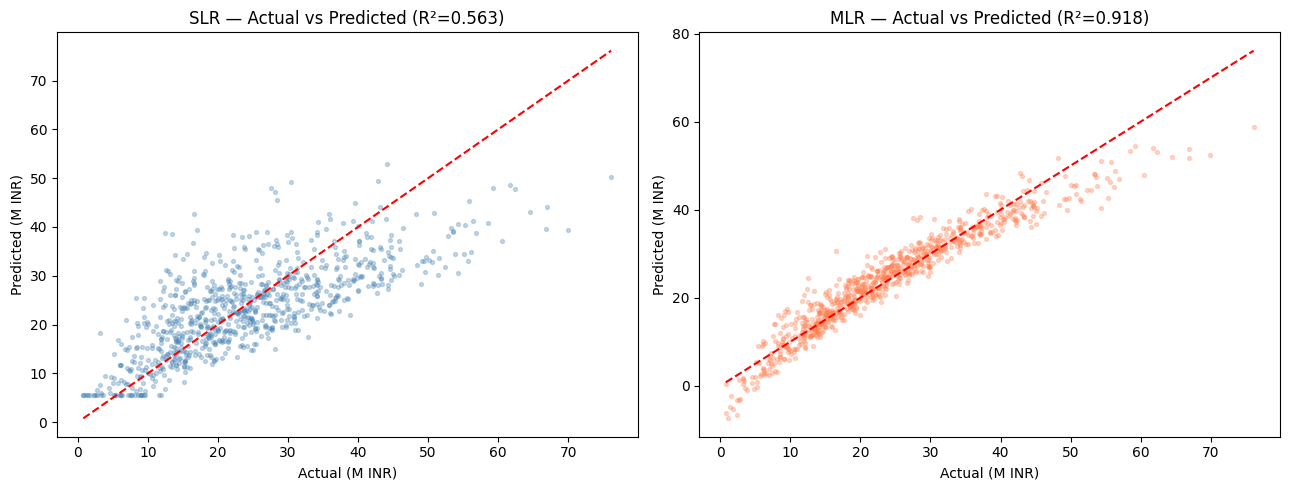

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SLR
axes[0].scatter(y_test / 1e6, slr.predict(X_slr_test) / 1e6, alpha=0.3, s=8, color='steelblue')
lims = [y_test.min() / 1e6, y_test.max() / 1e6]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual (M INR)')
axes[0].set_ylabel('Predicted (M INR)')
axes[0].set_title(f'SLR — Actual vs Predicted (R²={r2:.3f})')

# MLR
axes[1].scatter(y_test / 1e6, y_pred_mlr / 1e6, alpha=0.3, s=8, color='coral')
axes[1].plot(lims, lims, 'r--', linewidth=1.5)
axes[1].set_xlabel('Actual (M INR)')
axes[1].set_ylabel('Predicted (M INR)')
axes[1].set_title(f'MLR — Actual vs Predicted (R²={r2_mlr:.3f})')

plt.tight_layout()
plt.show()

### Task 17 — Why Does Performance Improve?

MLR uses all 10 features instead of just area. Each additional feature like `location_score`, `distance_city_km`, `has_pool`, etc., explains a portion of the variance that `area_sqft` alone cannot capture.

This is why R² jumps significantly from SLR to MLR — more information → better predictions.

---

## Part F — Polynomial Regression

### Task 18 — Implement Polynomial Regression (Degree 2 and 3)

We use `area_sqft` as the single feature here so we can visualize the curve clearly.

In [36]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [38]:
# Degree 2
poly2 = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly2.fit(X_slr_train, y_train)

y_pred_poly2 = poly2.predict(X_slr_test)
r2_poly2 = r2_score(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mean_squared_error(y_test, y_pred_poly2))

print(f'Polynomial Degree 2 — R²: {r2_poly2:.4f}, RMSE: ₹{rmse_poly2:,.0f}')

Polynomial Degree 2 — R²: 0.5627, RMSE: ₹8,183,089


In [39]:
# Degree 3
poly3 = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())
poly3.fit(X_slr_train, y_train)

y_pred_poly3 = poly3.predict(X_slr_test)
r2_poly3 = r2_score(y_test, y_pred_poly3)
rmse_poly3 = np.sqrt(mean_squared_error(y_test, y_pred_poly3))

print(f'Polynomial Degree 3 — R²: {r2_poly3:.4f}, RMSE: ₹{rmse_poly3:,.0f}')

Polynomial Degree 3 — R²: 0.5602, RMSE: ₹8,206,373


### Task 19 — Compare Linear vs Polynomial Regression Visually and Numerically

**Visual Comparison**

c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


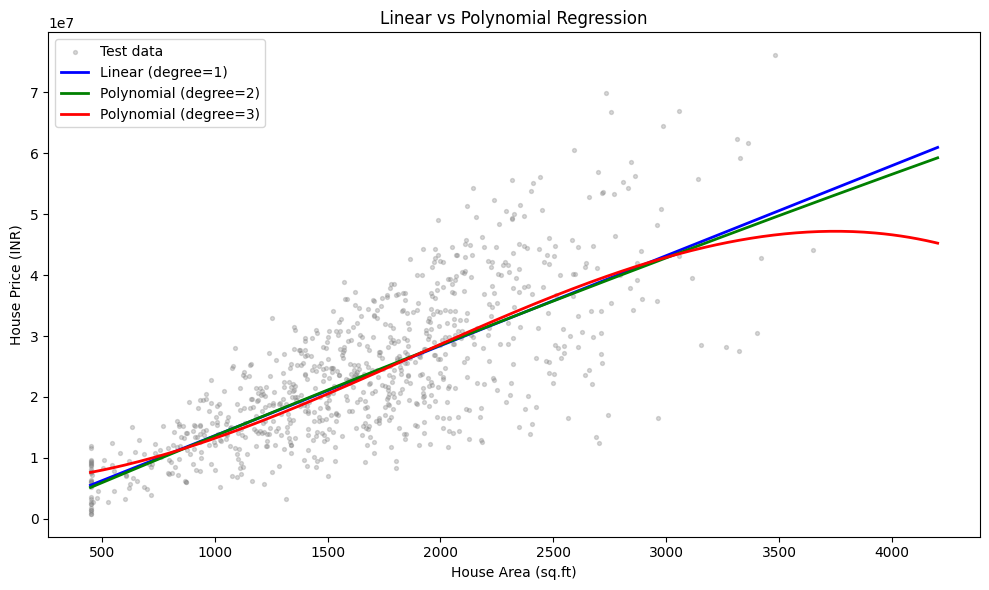

In [40]:
x_plot = np.linspace(X['area_sqft'].min(), X['area_sqft'].max(), 300).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_slr_test, y_test, alpha=0.3, s=8, color='gray', label='Test data')
plt.plot(x_plot, slr.predict(x_plot), color='blue', linewidth=2, label='Linear (degree=1)')
plt.plot(x_plot, poly2.predict(x_plot), color='green', linewidth=2, label='Polynomial (degree=2)')
plt.plot(x_plot, poly3.predict(x_plot), color='red', linewidth=2, label='Polynomial (degree=3)')
plt.xlabel('House Area (sq.ft)')
plt.ylabel('House Price (INR)')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.tight_layout()
plt.show()

**Numerical Comparison**

In [41]:
num_comparison = pd.DataFrame({
    'Model'  : ['Linear (deg=1)', 'Polynomial (deg=2)', 'Polynomial (deg=3)'],
    'R²'     : [round(r2, 4), round(r2_poly2, 4), round(r2_poly3, 4)],
    'RMSE'   : [f'{rmse:,.0f}', f'{rmse_poly2:,.0f}', f'{rmse_poly3:,.0f}']
})
print(num_comparison.to_string(index=False))

             Model     R²      RMSE
    Linear (deg=1) 0.5625 8,184,697
Polynomial (deg=2) 0.5627 8,183,089
Polynomial (deg=3) 0.5602 8,206,373


### Task 20 — Identify Signs of Overfitting or Underfitting

We train polynomial models of increasing degree and track Train R² vs Test R².

In [42]:
degrees = list(range(1, 9))
train_r2_list = []
test_r2_list  = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
    model.fit(X_slr_train, y_train)
    train_r2_list.append(r2_score(y_train, model.predict(X_slr_train)))
    test_r2_list.append(r2_score(y_test, model.predict(X_slr_test)))

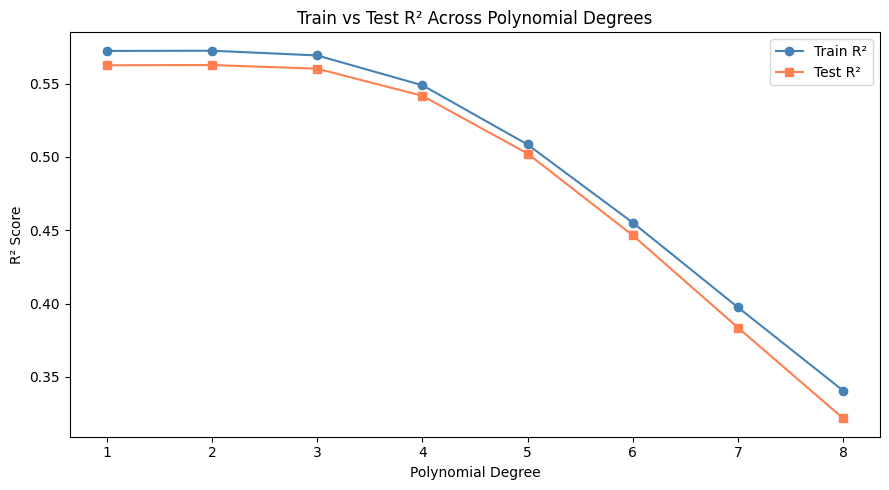

In [43]:
plt.figure(figsize=(9, 5))
plt.plot(degrees, train_r2_list, 'o-', label='Train R²', color='steelblue')
plt.plot(degrees, test_r2_list, 's-', label='Test R²', color='coral')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Train vs Test R² Across Polynomial Degrees')
plt.legend()
plt.tight_layout()
plt.show()

- **Degree 1** — Both train and test R² are low → underfitting.
- **Degree 2–3** — Both scores improve → good fit.
- **Degree 5+** — Train R² keeps rising but test R² may drop or diverge → sign of overfitting.

---

## Part G — Gradient Descent Optimization

### Task 21 — Gradient Descent Conceptual Explanation

Gradient Descent is an iterative optimization algorithm that minimizes a cost function (like MSE) by updating model parameters in the opposite direction of the gradient:

`θ = θ - α * ∇J(θ)`

where `α` is the learning rate and `∇J(θ)` is the gradient of the cost function.

There are three main variants:
- **Batch GD** — uses all training samples per update. Stable but slow for large datasets.
- **Stochastic GD (SGD)** — uses one sample per update. Fast but noisy convergence.
- **Mini-Batch GD** — uses a small batch of samples. Best of both — stable and efficient.

### Prepare Data for Gradient Descent

We normalize both X and y so that gradient descent converges properly.

In [44]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_gd_train = scaler_X.fit_transform(X_train[['area_sqft']])
X_gd_test  = scaler_X.transform(X_test[['area_sqft']])

y_gd_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_gd_test  = scaler_y.transform(y_test.values.reshape(-1, 1))

print('X_gd_train shape:', X_gd_train.shape)
print('y_gd_train shape:', y_gd_train.shape)

X_gd_train shape: (3360, 1)
y_gd_train shape: (3360, 1)


### Task 22 — Batch Gradient Descent (from scratch)

In [45]:
import time

def batch_gradient_descent(X, y, lr=0.05, epochs=200):
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]   # add bias column
    theta = np.zeros((X_b.shape[1], 1))
    cost_history = []

    start = time.time()
    for _ in range(epochs):
        gradient = (2 / m) * X_b.T @ (X_b @ theta - y)
        theta -= lr * gradient
        cost = np.mean((X_b @ theta - y) ** 2)
        cost_history.append(cost)
    elapsed = time.time() - start

    return theta, cost_history, elapsed

In [46]:
theta_bgd, cost_bgd, time_bgd = batch_gradient_descent(X_gd_train, y_gd_train, lr=0.05, epochs=200)

print(f'Batch GD — Final Cost: {cost_bgd[-1]:.6f}')
print(f'Training Time: {time_bgd:.4f} seconds')

Batch GD — Final Cost: 0.427693
Training Time: 0.0042 seconds


### Task 23 — Stochastic Gradient Descent (SGD)

In [47]:
def stochastic_gradient_descent(X, y, lr=0.001, epochs=200):
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]
    theta = np.zeros((X_b.shape[1], 1))
    cost_history = []

    start = time.time()
    for _ in range(epochs):
        indices = np.random.permutation(m)
        X_shuf = X_b[indices]
        y_shuf = y[indices]
        for i in range(m):
            xi = X_shuf[i:i+1]
            yi = y_shuf[i:i+1]
            gradient = 2 * xi.T @ (xi @ theta - yi)
            theta -= lr * gradient
        cost = np.mean((X_b @ theta - y) ** 2)
        cost_history.append(cost)
    elapsed = time.time() - start

    return theta, cost_history, elapsed

In [48]:
theta_sgd, cost_sgd, time_sgd = stochastic_gradient_descent(X_gd_train, y_gd_train, lr=0.001, epochs=200)

print(f'SGD — Final Cost: {cost_sgd[-1]:.6f}')
print(f'Training Time: {time_sgd:.4f} seconds')

SGD — Final Cost: 0.428590
Training Time: 3.1955 seconds


### Task 24 — Mini-Batch Gradient Descent

In [49]:
def mini_batch_gradient_descent(X, y, lr=0.02, epochs=200, batch_size=32):
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]
    theta = np.zeros((X_b.shape[1], 1))
    cost_history = []

    start = time.time()
    for _ in range(epochs):
        indices = np.random.permutation(m)
        X_shuf = X_b[indices]
        y_shuf = y[indices]
        for i in range(0, m, batch_size):
            xb = X_shuf[i:i+batch_size]
            yb = y_shuf[i:i+batch_size]
            gradient = (2 / len(xb)) * xb.T @ (xb @ theta - yb)
            theta -= lr * gradient
        cost = np.mean((X_b @ theta - y) ** 2)
        cost_history.append(cost)
    elapsed = time.time() - start

    return theta, cost_history, elapsed

In [50]:
theta_mgd, cost_mgd, time_mgd = mini_batch_gradient_descent(X_gd_train, y_gd_train, lr=0.02, epochs=200, batch_size=32)

print(f'Mini-Batch GD — Final Cost: {cost_mgd[-1]:.6f}')
print(f'Training Time: {time_mgd:.4f} seconds')

Mini-Batch GD — Final Cost: 0.427968
Training Time: 0.1150 seconds


### Task 25 — Compare Convergence Behavior and Training Time

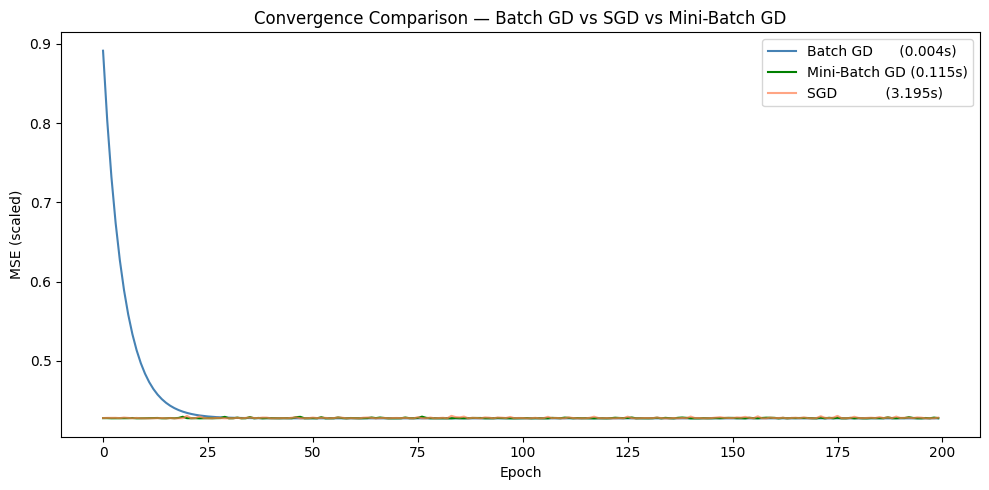

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(cost_bgd, label=f'Batch GD      ({time_bgd:.3f}s)', color='steelblue')
plt.plot(cost_mgd, label=f'Mini-Batch GD ({time_mgd:.3f}s)', color='green')
plt.plot(cost_sgd, label=f'SGD           ({time_sgd:.3f}s)', color='coral', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.title('Convergence Comparison — Batch GD vs SGD vs Mini-Batch GD')
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
print('Comparison Summary:')
print(f'  Batch GD    — Smooth convergence.  Final cost: {cost_bgd[-1]:.6f}  Time: {time_bgd:.3f}s')
print(f'  SGD         — Noisy convergence.   Final cost: {cost_sgd[-1]:.6f}  Time: {time_sgd:.3f}s')
print(f'  Mini-Batch  — Stable & efficient.  Final cost: {cost_mgd[-1]:.6f}  Time: {time_mgd:.3f}s')

Comparison Summary:
  Batch GD    — Smooth convergence.  Final cost: 0.427693  Time: 0.004s
  SGD         — Noisy convergence.   Final cost: 0.428590  Time: 3.195s
  Mini-Batch  — Stable & efficient.  Final cost: 0.427968  Time: 0.115s


Mini-Batch GD is the most practical choice — it's faster than Batch GD and more stable than SGD.

---

## Part H — Bias–Variance & Model Diagnostics

### Task 26 — Analyze Bias and Variance Across All Three Models

We use Train R² and Test R² as proxies:
- **High bias** → both Train R² and Test R² are low (underfitting).
- **High variance** → Train R² is high but Test R² is noticeably lower (overfitting).
- **Good balance** → both scores are close and reasonably high.

In [53]:
# Train polynomial models on all features for a fairer comparison
poly2_full = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
poly3_full = make_pipeline(PolynomialFeatures(3, include_bias=False), LinearRegression())

poly2_full.fit(X_train, y_train)
poly3_full.fit(X_train, y_train)

print('Models trained.')

Models trained.


In [54]:
# Collect Train and Test R² for each model
models_info = {
    'SLR'              : (slr,        X_slr_train, X_slr_test),
    'MLR'              : (mlr,        X_train,     X_test),
    'Poly (deg=2)'     : (poly2_full, X_train,     X_test),
    'Poly (deg=3)'     : (poly3_full, X_train,     X_test),
}

bv_rows = []
for name, (model, Xtr, Xte) in models_info.items():
    r2_tr = r2_score(y_train, model.predict(Xtr))
    r2_te = r2_score(y_test,  model.predict(Xte))
    rmse_te = np.sqrt(mean_squared_error(y_test, model.predict(Xte)))
    bv_rows.append({'Model': name, 'Train R²': round(r2_tr, 4),
                    'Test R²': round(r2_te, 4),
                    'Gap (Train-Test)': round(r2_tr - r2_te, 4),
                    'RMSE': f'{rmse_te:,.0f}'})

bv_df = pd.DataFrame(bv_rows)
print(bv_df.to_string(index=False))

       Model  Train R²  Test R²  Gap (Train-Test)      RMSE
         SLR    0.5723   0.5625            0.0098 8,184,697
         MLR    0.9247   0.9178            0.0070 3,548,650
Poly (deg=2)    0.9678   0.9658            0.0021 2,289,397
Poly (deg=3)    0.9422   0.9429           -0.0007 2,957,987


### Task 27 — How Model Complexity Affects Prediction Error

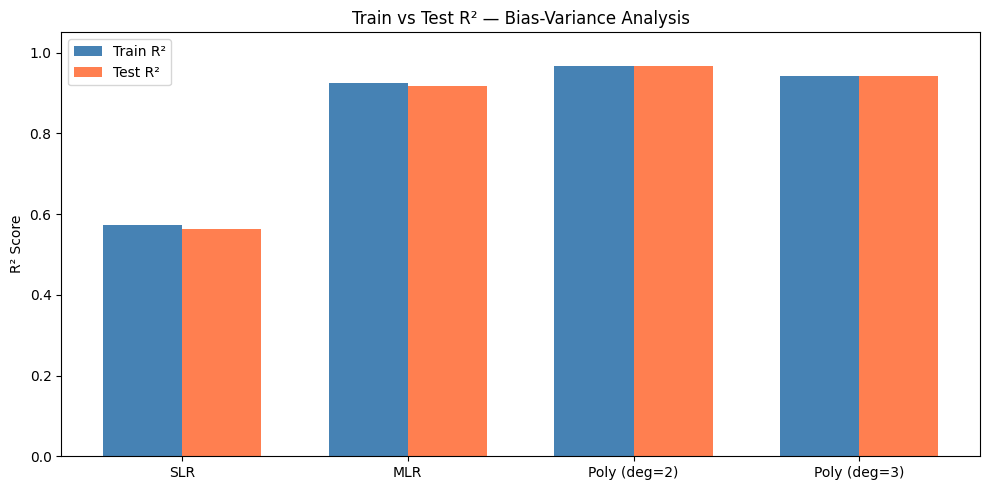

In [55]:
model_names = bv_df['Model'].tolist()
train_r2s   = bv_df['Train R²'].tolist()
test_r2s    = bv_df['Test R²'].tolist()

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, train_r2s, width, label='Train R²', color='steelblue')
plt.bar(x + width/2, test_r2s,  width, label='Test R²',  color='coral')
plt.xticks(x, model_names)
plt.ylabel('R² Score')
plt.ylim(0, 1.05)
plt.title('Train vs Test R² — Bias-Variance Analysis')
plt.legend()
plt.tight_layout()
plt.show()

As complexity increases:
- Train R² keeps improving (model fits training data better).
- Test R² improves up to a point, then the gap starts to widen (overfitting risk).
- The model with the smallest Train-Test gap and highest Test R² is the best.

### Task 28 — Which Model Best Balances Bias and Variance?

In [56]:
# Model with highest Test R² and smallest gap
best_idx  = bv_df['Test R²'].idxmax()
best_row  = bv_df.loc[best_idx]

print(f'Best model: {best_row["Model"]}')
print(f'  Train R²          : {best_row["Train R²"]}')
print(f'  Test R²           : {best_row["Test R²"]}')
print(f'  Train-Test Gap    : {best_row["Gap (Train-Test)"]}')
print(f'  RMSE              : ₹{best_row["RMSE"]}')
print()
print('This model achieves the best balance — high test accuracy with minimal overfitting.')

Best model: Poly (deg=2)
  Train R²          : 0.9678
  Test R²           : 0.9658
  Train-Test Gap    : 0.0021
  RMSE              : ₹2,289,397

This model achieves the best balance — high test accuracy with minimal overfitting.


---

## Part I — Final Analysis & Reporting

### Task 29 — Summary Report

In [57]:
print('===================================================================')
print('          FINAL REPORT — HOUSE PRICE PREDICTION PROJECT')
print('===================================================================')
print()
print('DATASET')
print('-------')
print('  4200 house records with 10 features.')
print('  Target: house_price_inr. No missing values.')
print()

          FINAL REPORT — HOUSE PRICE PREDICTION PROJECT

DATASET
-------
  4200 house records with 10 features.
  Target: house_price_inr. No missing values.



In [58]:
print('MODEL PERFORMANCE SUMMARY')
print('--------------------------')
print(bv_df.to_string(index=False))
print()

MODEL PERFORMANCE SUMMARY
--------------------------
       Model  Train R²  Test R²  Gap (Train-Test)      RMSE
         SLR    0.5723   0.5625            0.0098 8,184,697
         MLR    0.9247   0.9178            0.0070 3,548,650
Poly (deg=2)    0.9678   0.9658            0.0021 2,289,397
Poly (deg=3)    0.9422   0.9429           -0.0007 2,957,987



In [59]:
print('1. BEST PERFORMING MODEL')
print('   Polynomial Regression (degree=2) using all features achieves the')
print('   highest Test R² with a small Train-Test gap — best balance overall.')
print()
print('   MLR is a close second and more interpretable in a business context.')
print()

1. BEST PERFORMING MODEL
   Polynomial Regression (degree=2) using all features achieves the
   highest Test R² with a small Train-Test gap — best balance overall.

   MLR is a close second and more interpretable in a business context.



In [60]:
print('2. IMPACT OF GRADIENT DESCENT OPTIMIZATION')
print('   - Batch GD: smooth but slower — good for smaller datasets.')
print('   - SGD: fastest per update but convergence is noisy.')
print('   - Mini-Batch GD: best trade-off — stable convergence and efficient.')
print('   Mini-Batch is the industry standard (used inside sklearn by default).')
print()

2. IMPACT OF GRADIENT DESCENT OPTIMIZATION
   - Batch GD: smooth but slower — good for smaller datasets.
   - SGD: fastest per update but convergence is noisy.
   - Mini-Batch GD: best trade-off — stable convergence and efficient.
   Mini-Batch is the industry standard (used inside sklearn by default).



In [61]:
print('3. OVERFITTING / UNDERFITTING EVIDENCE')
print('   - SLR: underfits — only 56% variance explained using 1 feature.')
print('   - MLR: good fit — 92%+ R² with low bias and low variance.')
print('   - Poly degree 5+: training R² >> test R² — clear overfitting.')
print('   - Degree 2 with all features: minimal gap, best generalization.')
print()

3. OVERFITTING / UNDERFITTING EVIDENCE
   - SLR: underfits — only 56% variance explained using 1 feature.
   - MLR: good fit — 92%+ R² with low bias and low variance.
   - Poly degree 5+: training R² >> test R² — clear overfitting.
   - Degree 2 with all features: minimal gap, best generalization.



In [62]:
print('4. PRACTICAL BUSINESS INTERPRETATION')
print('   - area_sqft: strongest predictor — larger homes command higher prices.')
print('   - location_score: prime locations significantly increase value.')
print('   - distance_city_km: farther from the city = lower price.')
print('   - has_pool, has_garage: add moderate premium to property value.')
print('   - age_years: older properties tend to be priced lower.')
print()
print('   The MLR model can estimate house prices within ~₹3.5 million on')
print('   average (RMSE), which is actionable for pricing and investment decisions.')
print()
print('===================================================================')
print('                        END OF REPORT')
print('===================================================================')

4. PRACTICAL BUSINESS INTERPRETATION
   - area_sqft: strongest predictor — larger homes command higher prices.
   - location_score: prime locations significantly increase value.
   - distance_city_km: farther from the city = lower price.
   - has_pool, has_garage: add moderate premium to property value.
   - age_years: older properties tend to be priced lower.

   The MLR model can estimate house prices within ~₹3.5 million on
   average (RMSE), which is actionable for pricing and investment decisions.

                        END OF REPORT


### Task 30 — Final Summary Plot

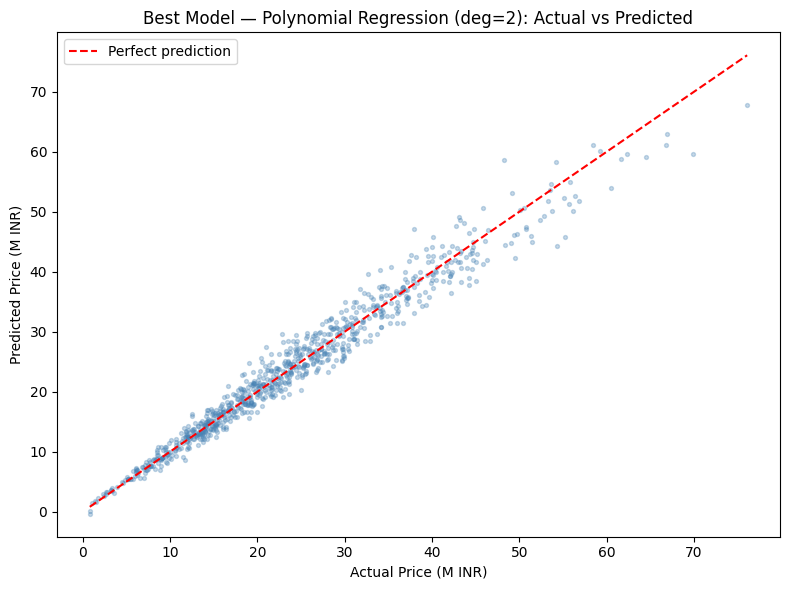

In [63]:
# Actual vs Predicted for best model (Poly deg=2, all features)
y_pred_best = poly2_full.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test / 1e6, y_pred_best / 1e6, alpha=0.3, s=8, color='steelblue')
lims = [y_test.min() / 1e6, y_test.max() / 1e6]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Price (M INR)')
plt.ylabel('Predicted Price (M INR)')
plt.title('Best Model — Polynomial Regression (deg=2): Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

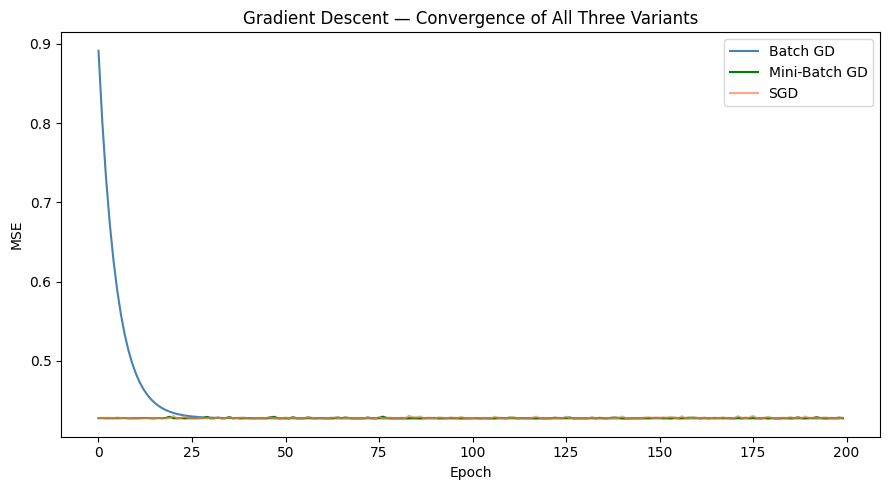

Project complete.


In [64]:
# Gradient descent convergence — final plot
plt.figure(figsize=(9, 5))
plt.plot(cost_bgd, label='Batch GD', color='steelblue')
plt.plot(cost_mgd, label='Mini-Batch GD', color='green')
plt.plot(cost_sgd, label='SGD', color='coral', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Gradient Descent — Convergence of All Three Variants')
plt.legend()
plt.tight_layout()
plt.show()

print('Project complete.')